### LSTM Model (Long Short-Term Memory)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os

os.chdir('C:/Users/gerar/OneDrive/Documentos/GitHub/bitcoinPred')  # Set the working directory

# Load and preprocess the data
def load_and_prepare_data(file_path, sequence_length=30):
    """
    Loads the dataset and prepares it for LSTM by creating sequences.

    Args:
        file_path (str): Path to the processed CSV file.
        sequence_length (int): Number of time steps in each sequence.

    Returns:
        X, y: Prepared sequences and corresponding targets.
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    # Scale the features to the range [0, 1]
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    # Create sequences
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])  # Sequence of features
        y.append(scaled_data[i, 0])  # Target is the 'close' price (first column)

    X, y = np.array(X), np.array(y)
    return X, y, scaler

# Build the LSTM model
def build_lstm_model(input_shape):
    """
    Builds an LSTM model.

    Args:
        input_shape (tuple): Shape of the input data (timesteps, features).

    Returns:
        model: Compiled LSTM model.
    """
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train the LSTM model
def train_lstm_model(X_train, y_train, X_val, y_val, input_shape, epochs=50, batch_size=32):
    """
    Trains the LSTM model.

    Args:
        X_train, y_train: Training data and targets.
        X_val, y_val: Validation data and targets.
        input_shape (tuple): Shape of the input data (timesteps, features).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.

    Returns:
        model: Trained LSTM model.
    """
    model = build_lstm_model(input_shape)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )
    return model, history

# Main execution block
file_path = "data/processed/btc_lstm.csv"  # Path to the LSTM-ready dataset
sequence_length = 30  # Number of time steps in each sequence

try:
    # Load and prepare the data
    X, y, scaler = load_and_prepare_data(file_path, sequence_length)

    # Split the data into training and validation sets (80% train, 20% validation)
    split_index = int(0.8 * len(X))
    X_train, X_val = X[:split_index], X[split_index:]
    y_train, y_val = y[:split_index], y[split_index:]

    # Train the LSTM model
    input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
    model, history = train_lstm_model(X_train, y_train, X_val, y_val, input_shape)

    print("Model training complete!")

except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")

c:\Users\gerar\OneDrive\Documentos\GitHub\bitcoinPred\bitcoinPredEnv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0043 - val_loss: 0.0073
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0013 - val_loss: 0.0041
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0011 - val_loss: 0.0091
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 7.4699e-04 - val_loss: 0.0063
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 8.7105e-04 - val_loss: 0.0056
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 7.0799e-04 - val_loss: 0.0041
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 7.5811e-04 - val_loss: 0.0036
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 6.3365e-04 - val_loss: 0.0126
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 8.0974e-04 - val_loss: 0.0031
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 7.3747e-04 - val_loss: 0.0042
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 6.5576e-04 - val_loss: 0.0032
Epoch 12/50
68/68 ━━━━━━━━━━━━

First iteration of the LSTM model

### Model Evaluation
#### Calculate metrics like Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on the validation set.

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Inverse transform the predictions and actual values to the original scale
y_val_pred_original = scaler.inverse_transform(np.concatenate((y_val_pred, np.zeros((y_val_pred.shape[0], X_val.shape[2] - 1))), axis=1))[:, 0]
y_val_original = scaler.inverse_transform(np.concatenate((y_val.reshape(-1, 1), np.zeros((y_val.shape[0], X_val.shape[2] - 1))), axis=1))[:, 0]

# Calculate evaluation metrics
mae = mean_absolute_error(y_val_original, y_val_pred_original)
rmse = np.sqrt(mean_squared_error(y_val_original, y_val_pred_original))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Mean Absolute Error (MAE): 2440.73
Root Mean Squared Error (RMSE): 3171.72


Evaluation of the first iteration shows that the model is not accurate.

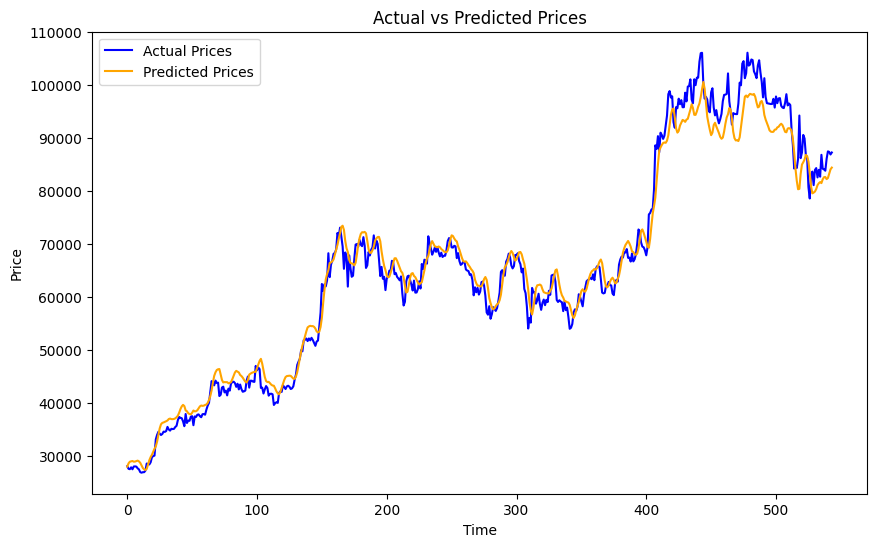

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_val_original, label="Actual Prices", color="blue")
plt.plot(y_val_pred_original, label="Predicted Prices", color="orange")
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

Graph to confirm accuracy.

#### Decrease the size of the data fed to the model

In [5]:
# Use the last 7 rows for training and the next row for testing
X_train, y_train = X[-8:-1], y[-8:-1]  # Last 7 rows
X_test, y_test = X[-1:], y[-1:]        # Current day (last row)

# Train the LSTM model
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
model, history = train_lstm_model(X_train, y_train, X_test, y_test, input_shape)

# Evaluate the model on the test set
y_test_pred = model.predict(X_test)

# Inverse transform the predictions and actual values to the original scale
y_test_pred_original = scaler.inverse_transform(np.concatenate((y_test_pred, np.zeros((y_test_pred.shape[0], X_test.shape[2] - 1))), axis=1))[:, 0]
y_test_original = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], X_test.shape[2] - 1))), axis=1))[:, 0]

print(f"Actual Price: {y_test_original[0]:.2f}")
print(f"Predicted Price: {y_test_pred_original[0]:.2f}")

Epoch 1/50


c:\Users\gerar\OneDrive\Documentos\GitHub\bitcoinPred\bitcoinPredEnv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.4748 - val_loss: 0.3275
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.3423 - val_loss: 0.1592
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.1627 - val_loss: 0.0489
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.0782 - val_loss: 0.0015
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0089 - val_loss: 0.0169
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.1056 - val_loss: 0.0384
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0624 - val_loss: 0.0440
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.0984 - val_loss: 0.0324
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0774 - val_loss: 0.0162
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
Actual Price: 87285.30
Predicted Price: 83258.55


Still inaccurate

#### Hyperparameter tuning

Epoch 1/50


c:\Users\gerar\OneDrive\Documentos\GitHub\bitcoinPred\bitcoinPredEnv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0145 - val_loss: 0.0145
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0020 - val_loss: 0.0094
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0016 - val_loss: 0.0059
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0015 - val_loss: 0.0075
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0013 - val_loss: 0.0067
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0013 - val_loss: 0.0086
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0010 - val_loss: 0.0079
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 8.8674e-04 - val_loss: 0.0072
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Mean Absolute Error (MAE): 6017.05
Root Mean Squared Error (RMSE): 8138.93


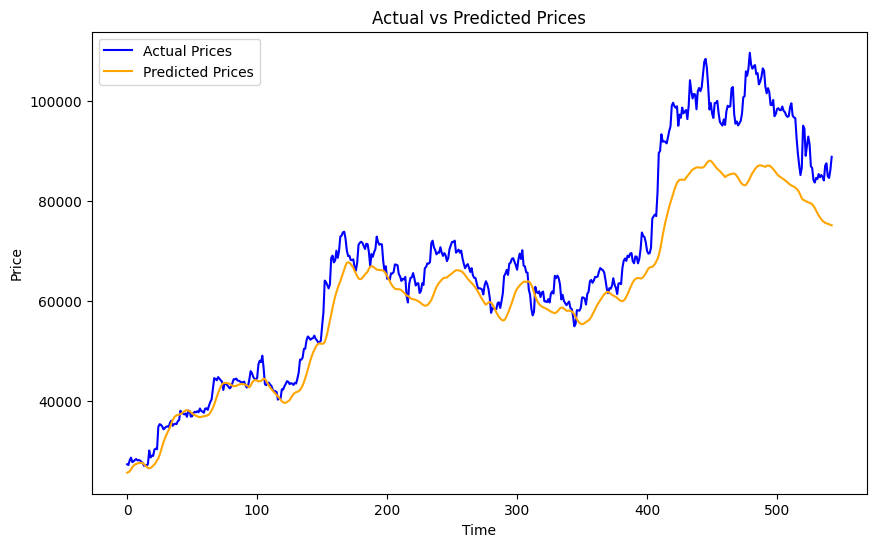

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Load and preprocess the data
def load_and_prepare_data(file_path, sequence_length=30):
    """
    Loads the dataset and prepares it for LSTM by creating sequences.

    Args:
        file_path (str): Path to the processed CSV file.
        sequence_length (int): Number of time steps in each sequence.

    Returns:
        X_train, X_val, y_train, y_val, scaler: Prepared sequences and corresponding targets.
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    # Select the relevant columns (all variables except the date column)
    df = df.iloc[:, 1:]  # Exclude the first column (date)

    # Scale the features using MinMaxScaler
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    # Create sequences
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])  # Sequence of features
        y.append(scaled_data[i, 0])  # Target is the 'close' price (first column)

    X, y = np.array(X), np.array(y)

    # Split into training and validation sets (80% train, 20% validation)
    split_index = int(0.8 * len(X))
    X_train, X_val = X[:split_index], X[split_index:]
    y_train, y_val = y[:split_index], y[split_index:]

    return X_train, X_val, y_train, y_val, scaler

# Build the LSTM model
def build_lstm_model(input_shape):
    """
    Builds an LSTM model.

    Args:
        input_shape (tuple): Shape of the input data (timesteps, features).

    Returns:
        model: Compiled LSTM model.
    """
    model = Sequential()
    model.add(LSTM(units=100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(units=1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train the LSTM model
def train_lstm_model(X_train, y_train, X_val, y_val, input_shape, epochs=50, batch_size=32):
    """
    Trains the LSTM model.

    Args:
        X_train, y_train: Training data and targets.
        X_val, y_val: Validation data and targets.
        input_shape (tuple): Shape of the input data (timesteps, features).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.

    Returns:
        model: Trained LSTM model.
        history: Training history object.
    """
    model = build_lstm_model(input_shape)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )
    return model, history

# Evaluate the model
def evaluate_model(model, X_val, y_val, scaler):
    """
    Evaluates the trained LSTM model on the validation set.

    Args:
        model: Trained LSTM model.
        X_val, y_val: Validation data and targets.
        scaler: Scaler used for normalization.

    Returns:
        None
    """
    # Make predictions on the validation set
    y_val_pred = model.predict(X_val)

    # Inverse transform the predictions and actual values to the original scale
    y_val_pred_original = scaler.inverse_transform(
        np.concatenate((y_val_pred, np.zeros((y_val_pred.shape[0], X_val.shape[2] - 1))), axis=1)
    )[:, 0]
    y_val_original = scaler.inverse_transform(
        np.concatenate((y_val.reshape(-1, 1), np.zeros((y_val.shape[0], X_val.shape[2] - 1))), axis=1)
    )[:, 0]

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_val_original, y_val_pred_original)
    rmse = np.sqrt(mean_squared_error(y_val_original, y_val_pred_original))

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

    # Plot actual vs predicted prices
    plt.figure(figsize=(10, 6))
    plt.plot(y_val_original, label="Actual Prices", color="blue")
    plt.plot(y_val_pred_original, label="Predicted Prices", color="orange")
    plt.title("Actual vs Predicted Prices")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # File path to the processed dataset
    file_path = "data/processed/btc_linear.csv"

    # Sequence length for LSTM
    sequence_length = 30

    # Load and prepare the data
    try:
        X_train, X_val, y_train, y_val, scaler = load_and_prepare_data(file_path, sequence_length)

        # Train the LSTM model
        input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
        model, history = train_lstm_model(X_train, y_train, X_val, y_val, input_shape)

        # Evaluate the model
        evaluate_model(model, X_val, y_val, scaler)

    except Exception as e:
        print(f"An error occurred: {e}")

Short term performance worsened.

#### Insight:
Despite performing poorly on the short term, LSTM seems to be a good fit to predict the medium to long term trend.

### RNN Model

Epoch 1/50


c:\Users\gerar\OneDrive\Documentos\GitHub\bitcoinPred\bitcoinPredEnv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.2745 - val_loss: 0.0185
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0823 - val_loss: 0.0058
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0343 - val_loss: 0.0015
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0225 - val_loss: 0.0035
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0163 - val_loss: 0.0014
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0131 - val_loss: 0.0020
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0096 - val_loss: 0.0057
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0077 - val_loss: 0.0051
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0073 - val_loss: 0.0012
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0060 - val_loss: 0.0039
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0052 - val_loss: 0.0014
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0049 - val_l

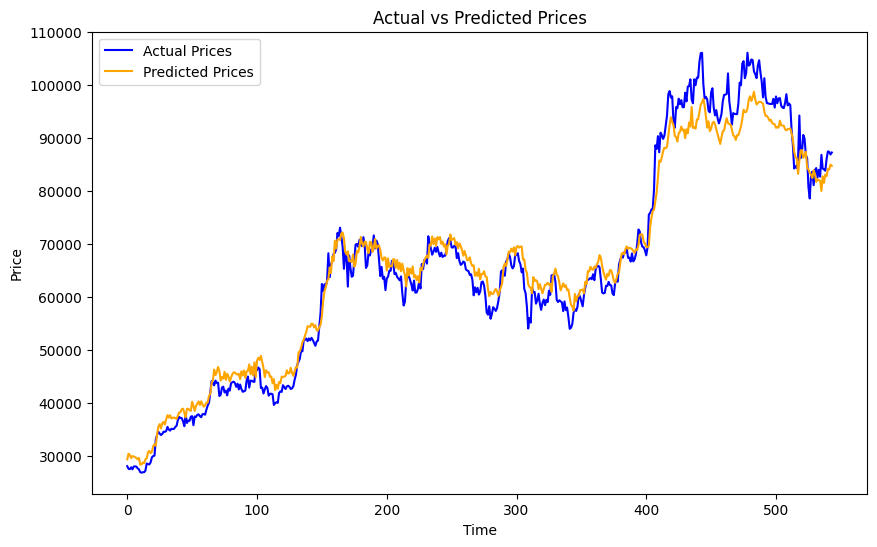

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Load and preprocess the data
def load_and_prepare_data(file_path, sequence_length=30):
    """
    Loads the dataset and prepares it for RNN by creating sequences.

    Args:
        file_path (str): Path to the processed CSV file.
        sequence_length (int): Number of time steps in each sequence.

    Returns:
        X_train, X_val, y_train, y_val, scaler: Prepared sequences and corresponding targets.
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    # Scale the features using MinMaxScaler
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    # Create sequences
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])  # Sequence of features
        y.append(scaled_data[i, 0])  # Target is the 'close' price (first column)

    X, y = np.array(X), np.array(y)

    # Split into training and validation sets (80% train, 20% validation)
    split_index = int(0.8 * len(X))
    X_train, X_val = X[:split_index], X[split_index:]
    y_train, y_val = y[:split_index], y[split_index:]

    return X_train, X_val, y_train, y_val, scaler

# Build the RNN model
def build_rnn_model(input_shape):
    """
    Builds an RNN model.

    Args:
        input_shape (tuple): Shape of the input data (timesteps, features).

    Returns:
        model: Compiled RNN model.
    """
    model = Sequential()
    model.add(SimpleRNN(units=100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(SimpleRNN(units=50, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(units=1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train the RNN model
def train_rnn_model(X_train, y_train, X_val, y_val, input_shape, epochs=50, batch_size=32):
    """
    Trains the RNN model.

    Args:
        X_train, y_train: Training data and targets.
        X_val, y_val: Validation data and targets.
        input_shape (tuple): Shape of the input data (timesteps, features).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.

    Returns:
        model: Trained RNN model.
        history: Training history object.
    """
    model = build_rnn_model(input_shape)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )
    return model, history

# Evaluate the model
def evaluate_model(model, X_val, y_val, scaler):
    """
    Evaluates the trained RNN model on the validation set.

    Args:
        model: Trained RNN model.
        X_val, y_val: Validation data and targets.
        scaler: Scaler used for normalization.

    Returns:
        None
    """
    # Make predictions on the validation set
    y_val_pred = model.predict(X_val)

    # Inverse transform the predictions and actual values to the original scale
    y_val_pred_original = scaler.inverse_transform(
        np.concatenate((y_val_pred, np.zeros((y_val_pred.shape[0], X_val.shape[2] - 1))), axis=1)
    )[:, 0]
    y_val_original = scaler.inverse_transform(
        np.concatenate((y_val.reshape(-1, 1), np.zeros((y_val.shape[0], X_val.shape[2] - 1))), axis=1)
    )[:, 0]

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_val_original, y_val_pred_original)
    rmse = np.sqrt(mean_squared_error(y_val_original, y_val_pred_original))

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

    # Plot actual vs predicted prices
    plt.figure(figsize=(10, 6))
    plt.plot(y_val_original, label="Actual Prices", color="blue")
    plt.plot(y_val_pred_original, label="Predicted Prices", color="orange")
    plt.title("Actual vs Predicted Prices")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # File path to the processed dataset
    file_path = "data/processed/btc_lstm.csv"

    # Sequence length for RNN
    sequence_length = 30

    # Load and prepare the data
    try:
        X_train, X_val, y_train, y_val, scaler = load_and_prepare_data(file_path, sequence_length)

        # Train the RNN model
        input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
        model, history = train_rnn_model(X_train, y_train, X_val, y_val, input_shape)

        # Evaluate the model
        evaluate_model(model, X_val, y_val, scaler)

    except Exception as e:
        print(f"An error occurred: {e}")

#### Insights:
RNN seems to outperform LSTM in the short term. But risk-wise, unlike RNN, LSTM lowballed its predictions, so, for risk management, seems like LSTM is a best alternative.